In [9]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [10]:
import os
import sys
import numpy as np
import pandas as pd
import itertools
import yaml
import requests
import matplotlib.pyplot as plt
import anndata as ad
from collections import OrderedDict
import seaborn as sns
import scanpy as sc
from cellsweep import denoise_count_matrix
import cellsweep.utils as cs_utils

cellsweep_dir = os.path.dirname(os.path.abspath(""))

# Compare CellBender vs. cellsweep

Some datasets of use:
- pbmc8k: 8k PBMCs from a healthy donor (CellBender Fig2): https://www.10xgenomics.com/datasets/8-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0
  - see run configuration on page 13 (bottom left) of the [Cellbender manuscript](https://doi.org/10.1038/s41592-023-01943-7)
- hgmm12k: Human-mouse mixture (CellBender Fig5): https://support.10xgenomics.com/single-cell-gene-expression/datasets/2.1.0/hgmm_12k

In [11]:
adata_raw_parent_dir = "/mnt/data1"
adata_filtered_dir = "/mnt/data1/8_cube"

verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False  # overwrite existing files
threads = 32  # for cellsweep and CellBender (if use_cuda=False)

In [12]:
dataset_name = "8cubed"

# create directories for data, output
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellsweep_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

eight_cubed_markers_path = os.path.join(data_dir, "8_cube_marker_genes.csv")

cellsweep_max_iter = 500
cellsweep_beta = 0.1
cellsweep_init_alpha = 0.9

if not os.path.exists(adata_raw_parent_dir):
    raise ValueError(f"adata_raw_parent_dir {adata_raw_parent_dir} does not exist.")
if not os.path.exists(adata_filtered_dir):
    raise ValueError(f"adata_filtered_dir {adata_filtered_dir} does not exist.")

In [13]:
plate_to_tissues = {}
plates = ["igvf_003", "igvf_004", "igvf_005", "igvf_007", "igvf_008b", "igvf_009", "igvf_010", "igvf_011"]
for plate in plates:
    plate_dir = os.path.join(adata_raw_parent_dir, plate)
    plate_to_tissues[plate] = [tissue for tissue in os.listdir(plate_dir)]
        
plate_to_tissues

{'igvf_003': ['CortexHippocampus', 'Heart'],
 'igvf_004': ['Liver', 'Heart'],
 'igvf_005': ['Liver', 'HypothalamusPituitary'],
 'igvf_007': ['HypothalamusPituitary', 'GonadsFemale', 'GonadsMale'],
 'igvf_008b': ['GonadsFemale', 'GonadsMale', 'Adrenal'],
 'igvf_009': ['Kidney', 'Adrenal'],
 'igvf_010': ['Kidney', 'Gastrocnemius'],
 'igvf_011': ['CortexHippocampus', 'Gastrocnemius']}

## Raw

In [ ]:
def load_8cubed_raw_data(adata_dir, backed=None, debug=False):
    # plate: adata
    try:
        from tqdm import tqdm
        tq = tqdm
    except ImportError:
        # no tqdm → identity function
        tq = lambda x, *args, **kwargs: x

    plates = ["igvf_003", "igvf_004", "igvf_005", "igvf_007", "igvf_008b", "igvf_009", "igvf_010", "igvf_011"]

    adata_dict = {}
    for plate in tq(plates, desc="Loading AnnData plates"):
        adatas_plate = []
        plate_dir = os.path.join(adata_dir, plate)
        tissues = os.listdir(plate_dir)
        if len(tissues) < 2 or len(tissues) > 3:
            print(f"[WARN] Plate directory {plate_dir} does not contain 2-3 tissues, skipping")
            continue
        for tissue in tissues:
            adata_path = os.path.join(plate_dir, tissue, "adata.h5ad")
            adata = ad.read_h5ad(adata_path, backed=backed)
            if debug:
                adata = adata[:10_000, :].to_memory()
            adata.var_names_make_unique()
            # merge GonadsMale and GonadsFemale into Gonads
            adata.obs["Tissue_original"] = adata.obs["Tissue"]
            adata.obs["Tissue"] = adata.obs["Tissue"].replace({
                "GonadsMale": "Gonads",
                "GonadsFemale": "Gonads",
            })
            adatas_plate.append(adata)
        adata_plate = ad.concat(adatas_plate, axis=0, join="inner", index_unique=None)
        adata_dict[plate] = adata_plate
    return adata_dict

def load_8cubed_filtered_data(adata_dir, backed="r", debug=False, obs_only=True):
    # tissue: adata
    try:
        from tqdm import tqdm
        tq = tqdm
    except ImportError:
        # no tqdm → identity function
        tq = lambda x, *args, **kwargs: x

    # List .h5ad files
    files = sorted([os.path.join(adata_dir, f) for f in os.listdir(adata_dir) if f.endswith(".h5ad")])

    if not files:
        raise ValueError(f"No .h5ad files found in: {adata_dir}")

    print(f"Found {len(files)} files:")
    for f in files:
        print("  -", f)

    # Load them
    adata_obs_dict = {}
    for filename in tq(files, desc="Loading AnnData obs-only"):
        tissue = os.path.basename(filename).replace("_annotated.h5ad", "")
        
        # Load metadata only
        adata = ad.read_h5ad(filename, backed=backed)
        obs = adata.obs.copy()   # copy small metadata only
        if obs_only:
            del adata                # drop the heavy object

        # Debug: limit rows
        if debug:
            obs = obs.iloc[:1_000].copy()

        # Tissue cleanup
        obs["Tissue_original"] = obs["Tissue"]
        obs["Tissue"] = obs["Tissue"].replace({
            "GonadsMale": "Gonads",
            "GonadsFemale": "Gonads",
        })

        # ensure correct index
        if "cellID" in obs.columns:
            obs = obs.set_index("cellID")

        if obs_only:
            adata_obs_dict[tissue] = obs
        else:
            adata.obs = obs
            adata_obs_dict[tissue] = adata

    # --- Combine Gonads (obs-only) ---
    if "GonadsMale" in adata_obs_dict and "GonadsFemale" in adata_obs_dict:
        if obs_only:
            adata_obs_dict["Gonads"] = pd.concat(
                [adata_obs_dict["GonadsMale"], adata_obs_dict["GonadsFemale"]],
                axis=0,
                join="inner"
            )
        else:
            adata_obs_dict["Gonads"] = adata_obs_dict["GonadsMale"].concatenate(adata_obs_dict["GonadsFemale"])
        
        del adata_obs_dict["GonadsMale"]
        del adata_obs_dict["GonadsFemale"]

    return adata_obs_dict

def merge_filtered_celltype_into_raw(adata_raw_dict, adata_filtered_tissue_obs_dict):
    adata_raw_plate_with_celltype_dict = {}

    for plate, adata in adata_raw_dict.items():
        if "celltype" in adata.obs.columns:
            print(f"[WARN] Plate {plate} already has celltype column — skipping")
            adata_raw_plate_with_celltype_dict[plate] = adata
            continue

        # Make a copy so original isn't modified
        # adata = adata.copy()

        # Start by initializing the column with Empty Droplet everywhere
        adata.obs["celltype"] = "Empty Droplet"

        # Loop over tissues for this plate
        for tissue in adata.obs["Tissue"].unique():

            if tissue not in adata_filtered_tissue_obs_dict:
                print(f"[WARN] Tissue {tissue} not in filtered dict — skipping")
                continue

            adata_obs_filtered = adata_filtered_tissue_obs_dict[tissue]

            if "celltype" not in adata_obs_filtered.columns:
                print(f"[WARN] Filtered {tissue} has no celltype column — skipping")
                continue

            # Filtered celltypes index
            filt_obs = adata_obs_filtered[["celltype"]].copy()

            # Only cells that exist in this raw plate
            common_idx = adata.obs.index.intersection(filt_obs.index)

            if len(common_idx) == 0:
                print(f"[INFO] No shared cells between plate {plate} and {tissue}")
                continue

            # Insert celltypes for those cells
            adata.obs.loc[common_idx, "celltype"] = filt_obs.loc[common_idx, "celltype"]

        # Store final annotated plate
        adata_raw_plate_with_celltype_dict[plate] = adata

    return adata_raw_plate_with_celltype_dict

In [ ]:
adata_raw_dict = load_8cubed_raw_data(adata_raw_parent_dir)
adata_filtered_tissue_obs_dict = load_8cubed_filtered_data(adata_filtered_dir)

Loading AnnData plates:  38%|███▊      | 3/8 [01:21<02:21, 28.33s/it]/tmp/ipykernel_1215524/200212014.py:28: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs["Tissue"] = adata.obs["Tissue"].replace({
/tmp/ipykernel_1215524/200212014.py:28: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs["Tissue"] = adata.obs["Tissue"].replace({
Loading AnnData plates:  50%|█████     | 4/8 [01:50<01:54, 28.67s/it]/tmp/ipykernel_1215524/200212014.py:28: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a futu

Found 9 files:
  - /mnt/data1/8_cube/Adrenal_annotated.h5ad
  - /mnt/data1/8_cube/CortexHippocampus_annotated.h5ad
  - /mnt/data1/8_cube/Gastrocnemius_annotated.h5ad
  - /mnt/data1/8_cube/GonadsFemale_annotated.h5ad
  - /mnt/data1/8_cube/GonadsMale_annotated.h5ad
  - /mnt/data1/8_cube/Heart_annotated.h5ad
  - /mnt/data1/8_cube/HypothalamusPituitary_annotated.h5ad
  - /mnt/data1/8_cube/Kidney_annotated.h5ad
  - /mnt/data1/8_cube/Liver_annotated.h5ad


Loading AnnData obs-only:  33%|███▎      | 3/9 [00:21<00:43,  7.26s/it]/tmp/ipykernel_1215524/200212014.py:72: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  obs["Tissue"] = obs["Tissue"].replace({
Loading AnnData obs-only:  44%|████▍     | 4/9 [00:25<00:29,  5.96s/it]/tmp/ipykernel_1215524/200212014.py:72: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  obs["Tissue"] = obs["Tissue"].replace({
Loading AnnData obs-only: 100%|██████████| 9/9 [01:07<00:00,  7.53s/it]


## Knee plot - use this output to estimate umi_cutoff

In [8]:
expected_cells = {plate: 0 for plate in adata_raw_dict.keys()}
for adata_obs in adata_filtered_tissue_obs_dict.values():
    for plate in adata_obs["plate"].unique():
        if plate in expected_cells:
            # sum value counts from adata
            expected_cells[plate] += int(adata_obs.loc[adata_obs["plate"] == plate, "n_counts"].value_counts().sum())
expected_cells

{'igvf_003': 639885,
 'igvf_004': 745458,
 'igvf_005': 694748,
 'igvf_007': 786528,
 'igvf_008b': 504134,
 'igvf_009': 641097,
 'igvf_010': 659512,
 'igvf_011': 721541}

UMI cutoff for expected cells (639885): 1047.00
UMI cutoff for expected cells (745458): 1132.00
UMI cutoff for expected cells (694748): 1056.00
UMI cutoff for expected cells (786528): 1353.00
UMI cutoff for expected cells (504134): 869.00
UMI cutoff for expected cells (641097): 1499.00
UMI cutoff for expected cells (659512): 1352.00
UMI cutoff for expected cells (721541): 952.00


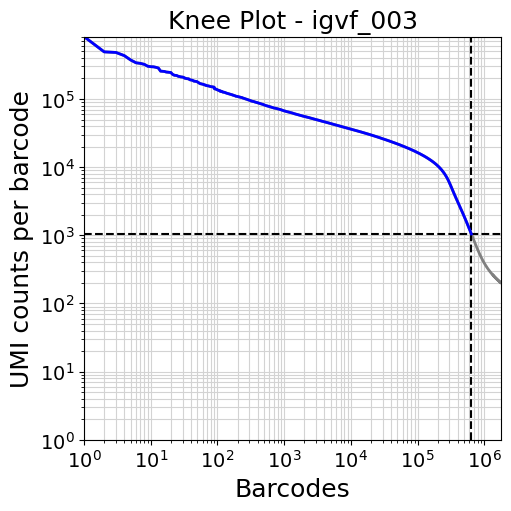

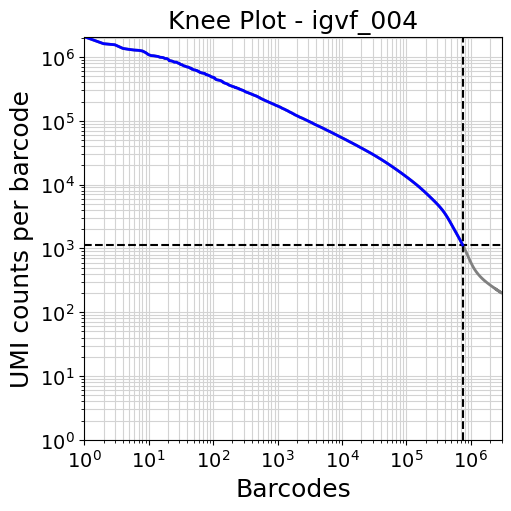

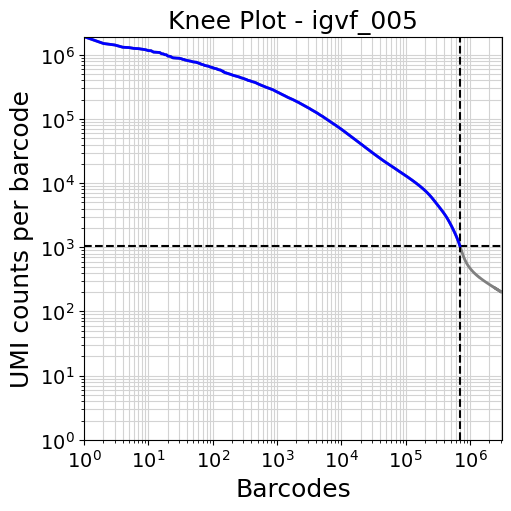

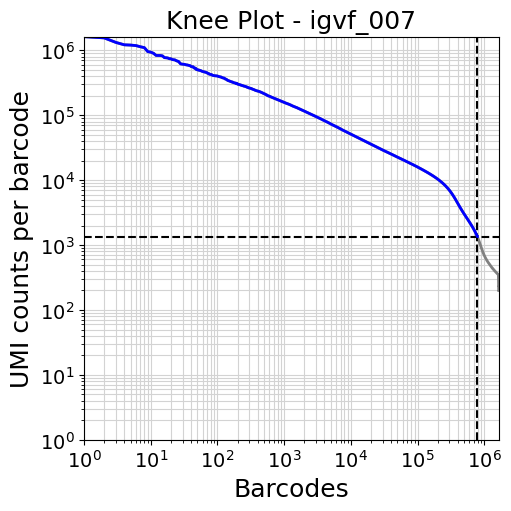

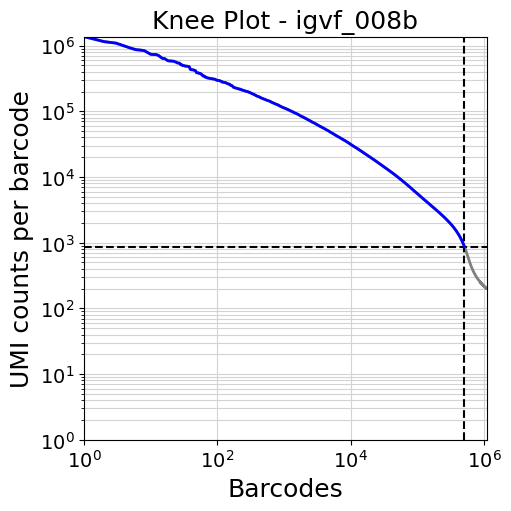

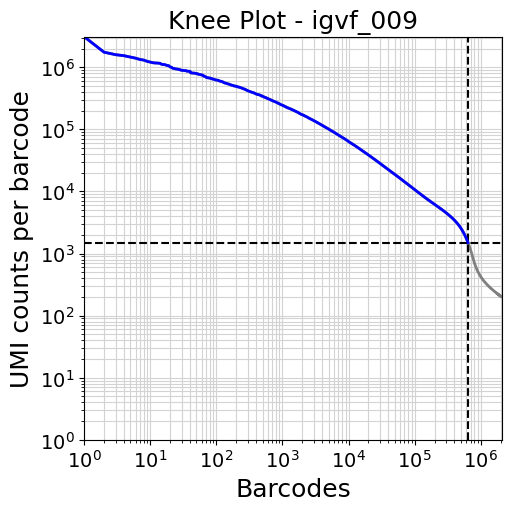

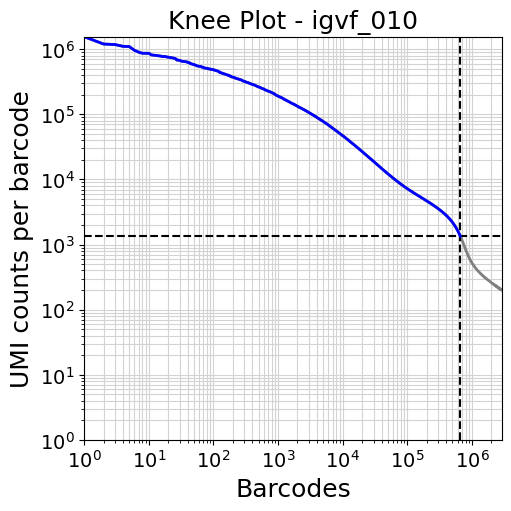

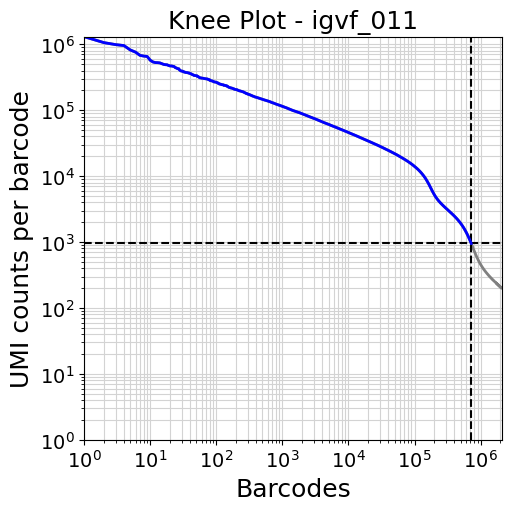

In [ ]:
umi_cutoffs = {}
for plate, adata_raw in adata_raw_dict.items():
    umi_cutoff = cs_utils.knee_plot(adata_raw, expected_cells=expected_cells[plate], title=f"Knee Plot - {plate}", out_path=os.path.join(out_dir, f"knee_plot_{plate}.png"))
    umi_cutoffs[plate] = umi_cutoff

In [10]:
#!!! optionally update umi_cutoffs from knee plot - required for None values
# umi_cutoffs = {
#     "igvf_003": None,
#     "igvf_004": None,
#     "igvf_005": None,
#     "igvf_007": None,
#     "igvf_008b": None,
#     "igvf_009": None,
#     "igvf_010": None,
#     "igvf_011": None,
# }

In [11]:
adata_raw_dict = merge_filtered_celltype_into_raw(adata_raw_dict, adata_filtered_tissue_obs_dict)

In [ ]:
adata_raw_filtered_dict = {}
for plate, adata_raw in adata_raw_dict.items():
    adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoffs[plate], verbose=verbose)  # adds adata.obs["is_empty"]
    adata_raw.var['empty_counts'] = np.array(adata_raw.X[adata_raw.obs['is_empty'].values, :].sum(axis=0)).flatten()
    adata_raw_dict[plate] = adata_raw
    adata_raw_filtered = adata_raw[~adata_raw.obs["is_empty"]].copy()
    adata_raw_filtered_dict[plate] = adata_raw_filtered

In [15]:
adata_raw_dict

{'igvf_003': AnnData object with n_obs × n_vars = 1787176 × 56953
     obs: 'bc', 'bc1_sequence', 'bc2_sequence', 'bc3_sequence', 'subpool', 'bc1_well', 'bc2_well', 'bc3_well', 'Mouse_Tissue_ID', 'alias_tissue1', 'alias_tissue2', 'alias_tissue3', 'alias_tissue4', 'plate', 'Protocol', 'Chemistry', 'well_type', 'Row', 'Column', 'Genotype', 'Notes', 'Multiplexed_sample1', 'Multiplexed_sample2', 'SampleType', 'Tissue', 'Tissue_ID', 'Tissue1_ontology_id', 'Tissue2_ontology_id', 'Sex', 'Replicate', 'DOB', 'Age_weeks', 'Age_days', 'Body_weight_g', 'Estrus_cycle', 'Dissection_date', 'Dissection_time', 'Dissector', 'Tissue_weight_mg', 'mult_genotype_1', 'mult_genotype_2', 'mult_genotype', 'n_counts', 'B6J', 'NODJ', '129S1J', 'CASTJ', 'AJ', 'PWKJ', 'WSBJ', 'NZOJ', 'doublet_scores', 'batch', 'Tissue_original', 'celltype', 'is_empty'
     var: 'empty_counts',
 'igvf_004': AnnData object with n_obs × n_vars = 3001436 × 56953
     obs: 'bc', 'bc1_sequence', 'bc2_sequence', 'bc3_sequence', 'subpool',

In [14]:
adata_raw_filtered_dict

{'igvf_003': AnnData object with n_obs × n_vars = 640029 × 56953
     obs: 'bc', 'bc1_sequence', 'bc2_sequence', 'bc3_sequence', 'subpool', 'bc1_well', 'bc2_well', 'bc3_well', 'Mouse_Tissue_ID', 'alias_tissue1', 'alias_tissue2', 'alias_tissue3', 'alias_tissue4', 'plate', 'Protocol', 'Chemistry', 'well_type', 'Row', 'Column', 'Genotype', 'Notes', 'Multiplexed_sample1', 'Multiplexed_sample2', 'SampleType', 'Tissue', 'Tissue_ID', 'Tissue1_ontology_id', 'Tissue2_ontology_id', 'Sex', 'Replicate', 'DOB', 'Age_weeks', 'Age_days', 'Body_weight_g', 'Estrus_cycle', 'Dissection_date', 'Dissection_time', 'Dissector', 'Tissue_weight_mg', 'mult_genotype_1', 'mult_genotype_2', 'mult_genotype', 'n_counts', 'B6J', 'NODJ', '129S1J', 'CASTJ', 'AJ', 'PWKJ', 'WSBJ', 'NZOJ', 'doublet_scores', 'batch', 'Tissue_original', 'celltype', 'is_empty'
     var: 'empty_counts',
 'igvf_004': AnnData object with n_obs × n_vars = 745765 × 56953
     obs: 'bc', 'bc1_sequence', 'bc2_sequence', 'bc3_sequence', 'subpool', '

## Save Anndatas

In [ ]:
for plate, adata in adata_raw_dict.items():
    adata_path = os.path.join(data_dir, plate, "raw_counts.h5ad")
    if not os.path.exists(adata_path):
        os.makedirs(os.path.dirname(adata_path), exist_ok=True)
        adata.write_h5ad(adata_path)

for plate, adata in adata_raw_filtered_dict.items():
    adata_path = os.path.join(data_dir, plate, "raw_counts_removed_empty_barcodes.h5ad")
    if not os.path.exists(adata_path):
        os.makedirs(os.path.dirname(adata_path), exist_ok=True)
        adata.write_h5ad(adata_path)

adata_filtered_tissue_dict = load_8cubed_filtered_data(adata_filtered_dir, backed=None, obs_only=False)
adata_cellbender_dict = {}
for tissue in adata_filtered_tissue_dict:
    print(f"Processing CellBender data from tissue {tissue}...")
    for plate in adata_filtered_tissue_dict[tissue].obs["plate"].unique().tolist():
        if plate not in plates:
            continue
        if plate not in adata_cellbender_dict:
            adata_cellbender_dict[plate] = adata_filtered_tissue_dict[tissue][adata_filtered_tissue_dict[tissue].obs["plate"] == plate].copy()
        else:
            adata_cellbender_dict[plate] = adata_cellbender_dict[plate].concatenate(adata_filtered_tissue_dict[tissue][adata_filtered_tissue_dict[tissue].obs["plate"] == plate])

for plate, adata in adata_cellbender_dict.items():
    adata_path = os.path.join(data_dir, plate, "cellbender.h5ad")
    if not os.path.exists(adata_path):
        os.makedirs(os.path.dirname(adata_path), exist_ok=True)
        adata.write_h5ad(adata_path)

## cellsweep

In [ ]:
# plates = ["igvf_003", "igvf_004", "igvf_005", "igvf_007", "igvf_008b", "igvf_009", "igvf_010", "igvf_011"]
# adata_raw_dict = {}
# for plate in plates:
#     adata_raw_dict[plate] = ad.read_h5ad(os.path.join(data_dir, plate, "raw_counts.h5ad"))

expected_cells = {
    'igvf_003': 639885,
    'igvf_004': 745458,
    'igvf_005': 694748,
    'igvf_007': 786528,
    'igvf_008b': 504134,
    'igvf_009': 641097,
    'igvf_010': 659512,
    'igvf_011': 721541
}

adata_cellsweep_dict = {}
# for plate, adata_raw in adata_raw_dict.items():
for plate in plates:   #? memory management
    print(f"Processing Cellsweep for plate {plate}...")
    adata_raw = ad.read_h5ad(os.path.join(data_dir, plate, "raw_counts.h5ad"))   #? memory management
    adata_path_cellsweep = os.path.join(data_dir, plate, "cellsweep.h5ad")
    cellsweep_log_path = os.path.join(data_dir, plate, "cellsweep.log")
    if not os.path.exists(adata_path_cellsweep) or overwrite:
        adata_cellsweep = denoise_count_matrix(adata_raw, adata_out=adata_path_cellsweep, beta=cellsweep_beta, freeze_ambient_profile=True, init_alpha=cellsweep_init_alpha, max_iter=cellsweep_max_iter, empty_droplet_method="threshold", expected_cells=expected_cells[plate], threads=threads, verbose=verbose, log_file=cellsweep_log_path)
    else:
        adata_cellsweep = ad.read_h5ad(adata_path_cellsweep)
    adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
    adata_cellsweep.var_names_make_unique()
    adata_filtered_path_cellsweep = os.path.join(data_dir, plate, "cellsweep_filtered.h5ad")
    if not os.path.exists(adata_filtered_path_cellsweep) or overwrite:
        adata_cellsweep.write_h5ad(adata_filtered_path_cellsweep)
    adata_cellsweep_dict[plate] = adata_cellsweep
    del adata_raw   #? memory management
    del adata_cellsweep   #? memory management

# for plate, adata in adata_cellsweep_dict.items():
#     adata_path = os.path.join(data_dir, plate, "cellsweep.h5ad")
#     if not os.path.exists(adata_path):
#         os.makedirs(os.path.dirname(adata_path), exist_ok=True)
#         adata.write_h5ad(adata_path)

# Analysis

In [ ]:
for plate in adata_raw_dict.keys():
    print(f"Plate: {plate}")
    # print(f"Adata raw (all barcodes): {adata_raw_dict[plate]}")
    # print(f"Adata raw (filtered barcodes): {adata_raw_filtered_dict[plate]}")
    print(f"Adata cellsweep: {adata_cellsweep_dict[plate]}\n\n")

## 8 Cubed Analysis

In [22]:
if not os.path.exists(eight_cubed_markers_path):
    eight_cubed_markers_url = "https://docs.google.com/spreadsheets/d/1RJHnxeobFfXAQdrUGAn4SWxQZzs0KaheuLJgNc6AjCg/export?format=csv&gid=0"
    r = requests.get(eight_cubed_markers_url)
    with open(eight_cubed_markers_path, "wb") as f:
        f.write(r.content)

eight_cubed_markers_df = pd.read_csv(eight_cubed_markers_path)
if "gene_id" not in eight_cubed_markers_df.columns:
    # make gene_name_to_symbol_df
    files = sorted([os.path.join(adata_filtered_dir, f) for f in os.listdir(adata_filtered_dir) if f.endswith(".h5ad")])
    first_file = files[0]
    adata_tmp = ad.read_h5ad(first_file, backed="r")
    gene_name_to_symbol_df = adata_tmp.var[["gene_name", "gene_id"]].copy()
    gene_name_to_symbol_df = gene_name_to_symbol_df.reset_index(drop=True)
    eight_cubed_markers_df = eight_cubed_markers_df.merge(gene_name_to_symbol_df, left_on="ai", right_on="gene_name", how="left")
    eight_cubed_markers_df.to_csv(eight_cubed_markers_path, index=False)

In [ ]:
import os
import anndata as ad
import pandas as pd
import numpy as np
import cellsweep.utils as cs_utils
cellsweep_dir = os.path.dirname(os.path.abspath(""))
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", "8cubed")
plates = ["igvf_003", "igvf_004", "igvf_005", "igvf_007", "igvf_008b", "igvf_009", "igvf_010", "igvf_011"]
adata_raw_filtered_dict, adata_cellsweep_dict = {}, {}
for plate in plates:
    print(f"Loading data for plate {plate}...")
    adata_raw_filtered = ad.read_h5ad(os.path.join(data_dir, plate, "raw_counts_removed_empty_barcodes.h5ad"))
    adata_raw_filtered.var_names_make_unique()
    adata_raw_filtered_dict[plate] = adata_raw_filtered
    
    adata_cellsweep = ad.read_h5ad(os.path.join(data_dir, plate, "cellsweep.h5ad"))
    adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
    adata_cellsweep.var_names_make_unique()
    adata_cellsweep_dict[plate] = adata_cellsweep

eight_cubed_markers_path = os.path.join(data_dir, "8_cube_marker_genes.csv")
out_dir = os.path.join(cellsweep_dir, "notebooks", "output", "8cubed")

# np.random.seed(42)
# adata_cellsweep_dict["igvf_003"] = adata_cellsweep_dict["igvf_003"][np.random.choice(adata_cellsweep_dict["igvf_003"].n_obs, size=5000, replace=False), :].copy()


import importlib
import cellsweep.utils.visualization_utils as visualization_utils
importlib.reload(visualization_utils)
importlib.reload(cs_utils)
dict_of_adata_dicts = {
    "raw": adata_raw_filtered_dict,
    "cellsweep": adata_cellsweep_dict,
}
cs_utils.make_8cubed_plots(dict_of_adata_dicts, eight_cubed_markers_path, out_dir=out_dir)

Plate igvf_003
                Tissue      gene_name                gene_id   ambient_hat  ambient_rank
226              Heart            Ttn  ENSMUSG00000051747.16  1.229538e-02             5
212              Heart           Myh6  ENSMUSG00000040752.17  3.334800e-03            18
261              Heart          Cadm2  ENSMUSG00000064115.14  2.597234e-03            23
221              Heart           Ryr2  ENSMUSG00000021313.17  1.621088e-03            42
5    CortexHippocampus         Slc1a2  ENSMUSG00000005089.16  1.456247e-03            51
166  CortexHippocampus         Camk2a  ENSMUSG00000024617.17  9.512655e-04            95
167  CortexHippocampus           Map2  ENSMUSG00000015222.19  8.649418e-04           109
211              Heart         Atp2a2  ENSMUSG00000029467.16  6.531913e-04           147
145  CortexHippocampus          Pde1a  ENSMUSG00000059173.20  5.295989e-04           209
188  CortexHippocampus          Cntn1  ENSMUSG00000055022.15  4.558135e-04           274
224   

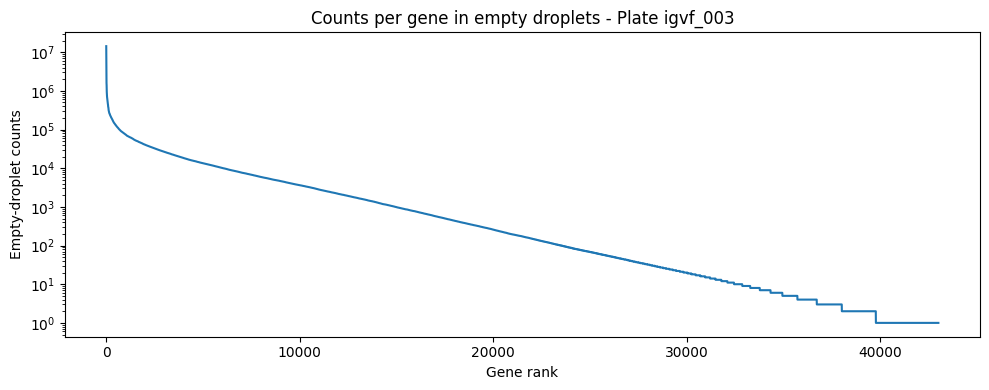

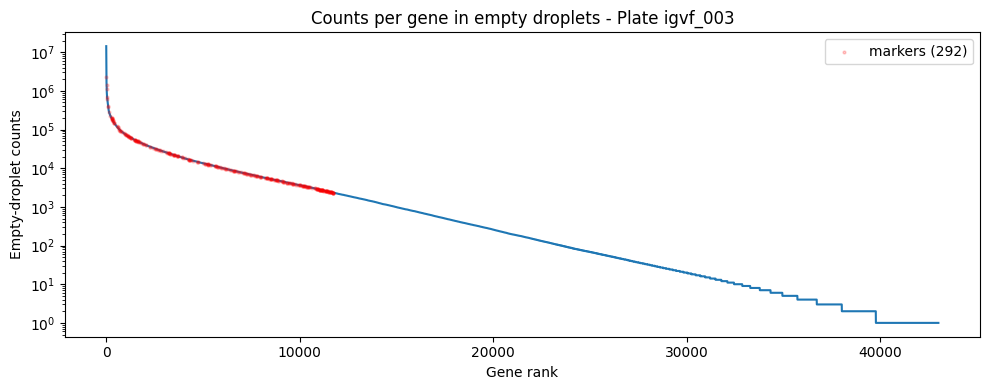

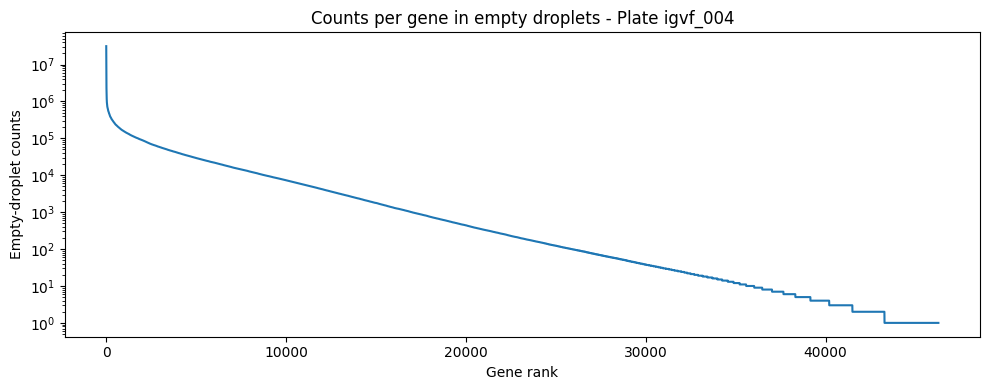

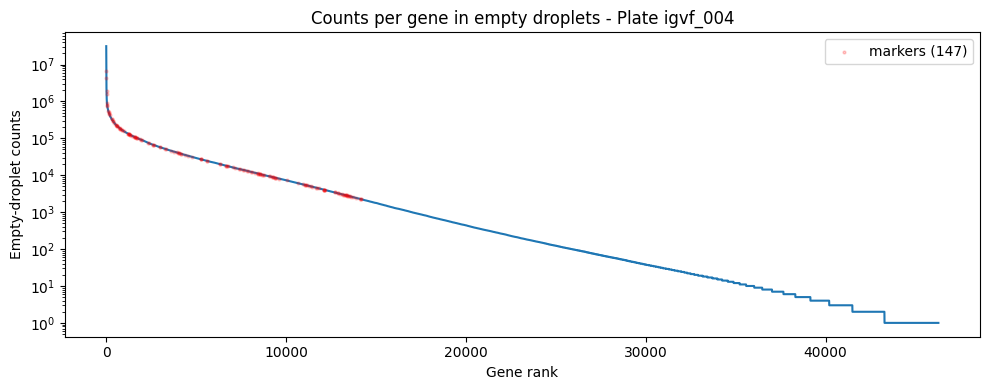

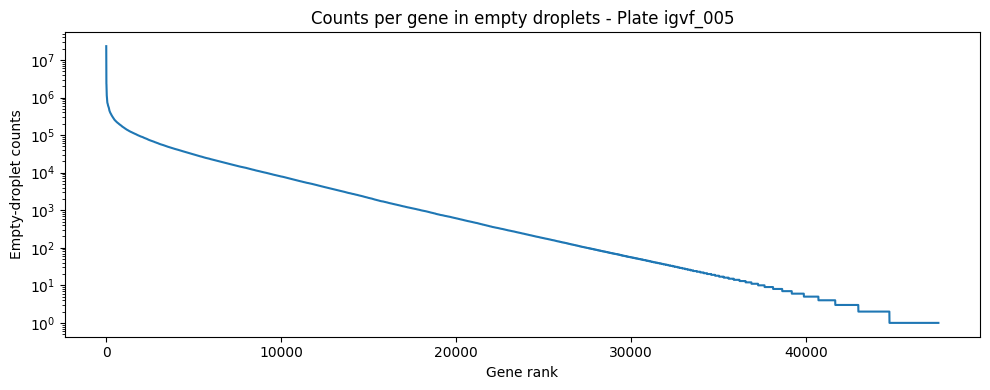

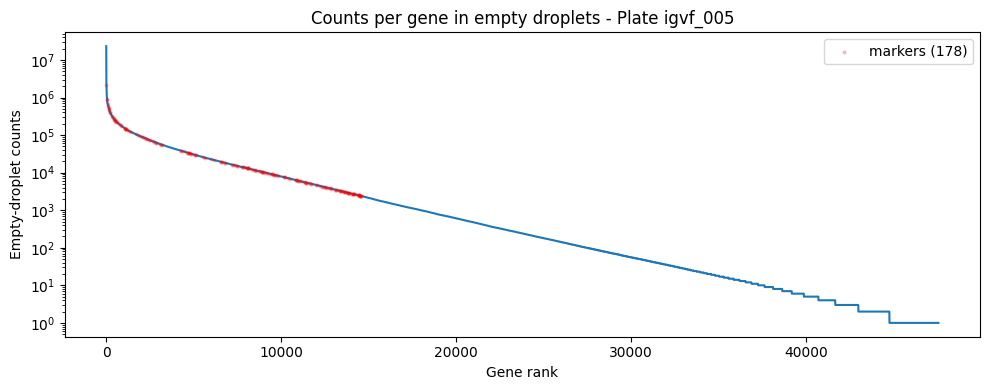

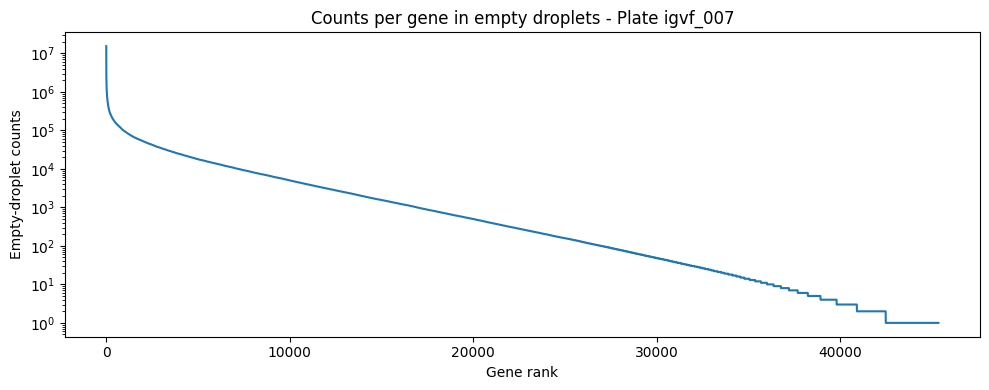

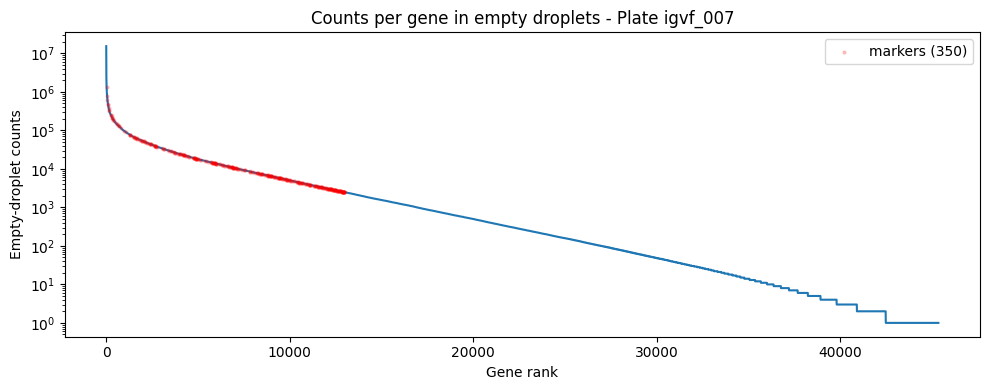

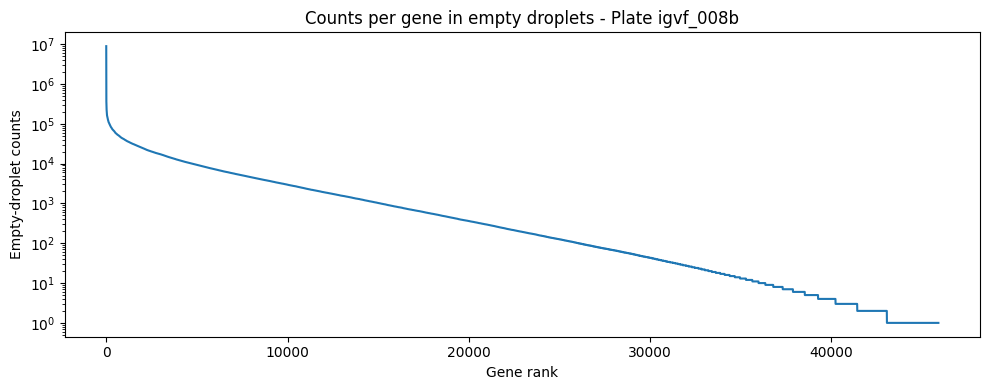

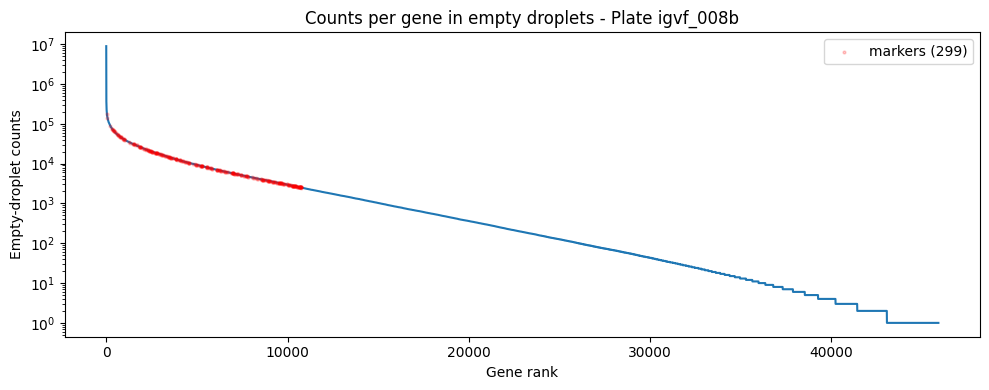

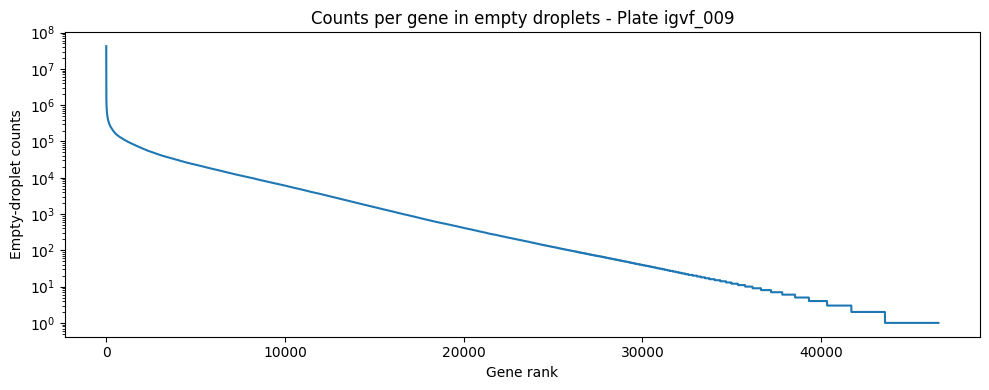

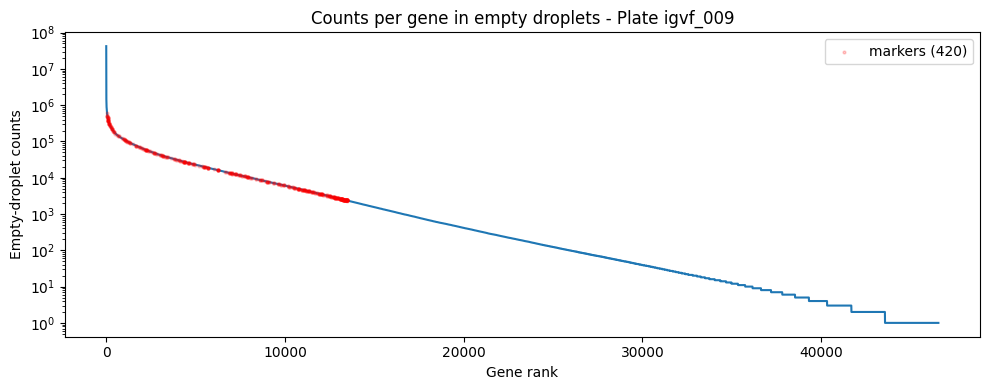

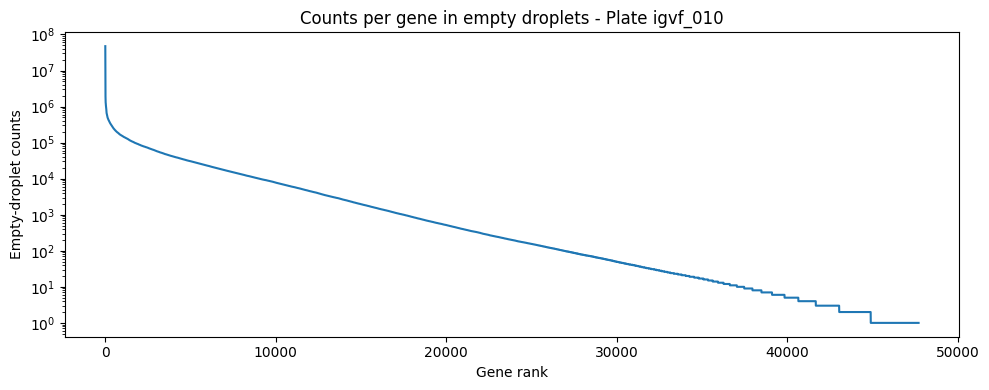

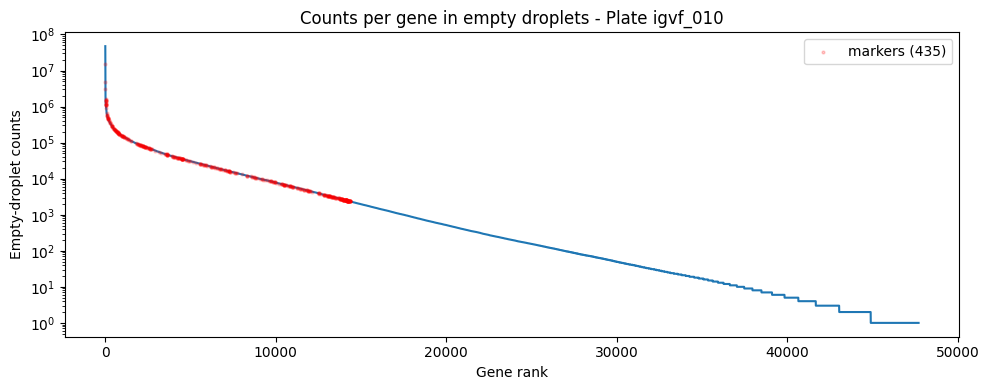

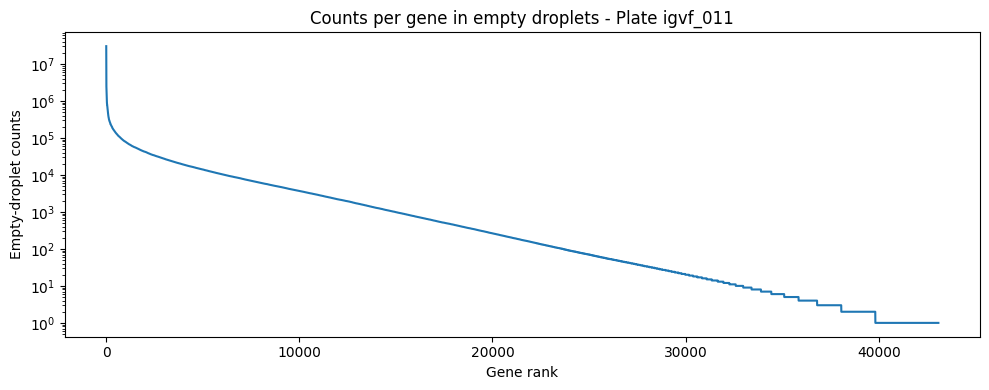

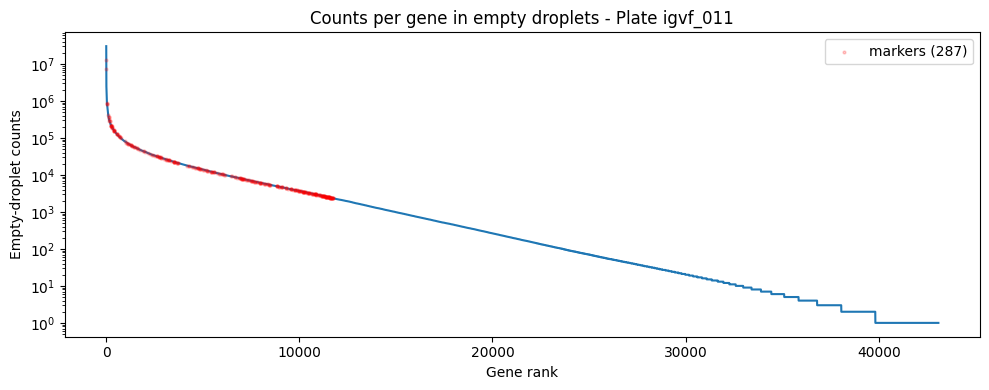

In [3]:
import anndata as ad
import os
import pandas as pd
import cellsweep.utils as cs_utils
cellsweep_dir = os.path.dirname(os.path.abspath(""))
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", "8cubed")
out_dir = os.path.join(cellsweep_dir, "notebooks", "output", "8cubed")
eight_cubed_markers_path = os.path.join(data_dir, "8_cube_marker_genes.csv")

eight_cubed_markers_df = pd.read_csv(eight_cubed_markers_path, usecols=["gene_id", "gene_name", "Tissue"])
eight_cubed_markers_df["Tissue"] = eight_cubed_markers_df["Tissue"].replace({
    "GonadsMale": "Gonads",
    "GonadsFemale": "Gonads",
})

plates = ["igvf_003", "igvf_004", "igvf_005", "igvf_007", "igvf_008b", "igvf_009", "igvf_010", "igvf_011"]
for plate in plates:
    print(f"Plate {plate}")
    adata_cellsweep = ad.read_h5ad(os.path.join(data_dir, plate, "cellsweep.h5ad"), backed="r")
    # adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
    adata_cellsweep.var_names_make_unique()

    # plot ambient genes predicted
    cs_utils.plot_empty_gene_counts(adata_cellsweep, title=f"Counts per gene in empty droplets - Plate {plate}", highlight_indices=None, out_path=os.path.join(out_dir, f"empty_gene_counts_plate_{plate}.png"), show=True)

    # look at the "true" ambient genes (ie the marker genes for the incorrect tissues)
    tissues = adata_cellsweep.obs["Tissue"].unique().tolist()
    if len(tissues) != 2:
        print(f"Warning: Plate {plate} does not have exactly 2 tissues in adata_cellsweep. Found tissues: {tissues}. Skipping.")
        continue

    eight_cubed_markers_df_filtered = eight_cubed_markers_df[eight_cubed_markers_df["Tissue"].isin(tissues)]

    adata_cellsweep.var["ambient_rank"] = adata_cellsweep.var["ambient_hat"].rank(ascending=False, method="dense")

    ambient_df = adata_cellsweep.var[["ambient_hat", "ambient_rank"]].copy()
    eight_cubed_markers_df_filtered = eight_cubed_markers_df_filtered.merge(ambient_df, on="gene_id", how="left")
    eight_cubed_markers_df_filtered["ambient_rank"] = eight_cubed_markers_df_filtered["ambient_rank"].astype("Int64")

    eight_cubed_markers_df_filtered = eight_cubed_markers_df_filtered.sort_values(by="ambient_rank", ascending=True)
    eight_cubed_markers_df_filtered = eight_cubed_markers_df_filtered[~eight_cubed_markers_df_filtered["ambient_rank"].isna()]

    # plot ambient genes predicted
    cs_utils.plot_empty_gene_counts(adata_cellsweep, title=f"Counts per gene in empty droplets - Plate {plate}", highlight_indices=eight_cubed_markers_df_filtered["ambient_rank"], out_path=os.path.join(out_dir, f"empty_gene_counts_plate_{plate}_with_overlay.png"), show=True)
    
    # print eight_cubed_markers_df_filtered sorted ascending by ambient_rank
    with pd.option_context(
        "display.max_rows", 500,
        "display.max_columns", None,
        "display.width", 10_000,       # huge width prevents line breaks
        "display.max_colwidth", None  # prevents truncation
    ):
        print(eight_cubed_markers_df_filtered.head(500))
    
    print("--------------------------------\n")

    # break